In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

ROOT = Path.cwd().parent

df = pd.read_csv(
    ROOT / "dataset" / "weather_featured.csv"
)

X = df.drop("Temperature", axis=1)
y = df["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("Temperature", axis=1)
y = df["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [3]:
from pathlib import Path
import joblib

ROOT = Path.cwd().parent
rf = joblib.load(ROOT / "models" / "weather_model.pkl")
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [4]:
y_pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.323208
MSE : 3.6730884539999997
RMSE: 1.91653031648341
R² Score: 0.8831461738458528


In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8831461738458528
MAE: 1.323208
RMSE: 1.91653031648341


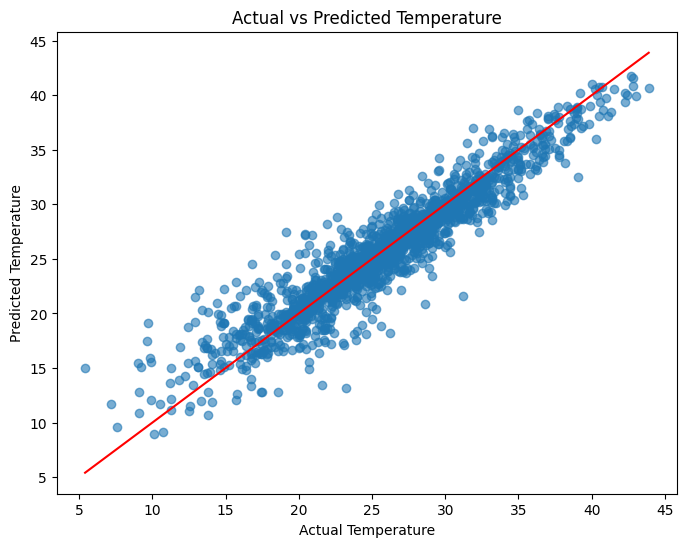

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Temperature")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

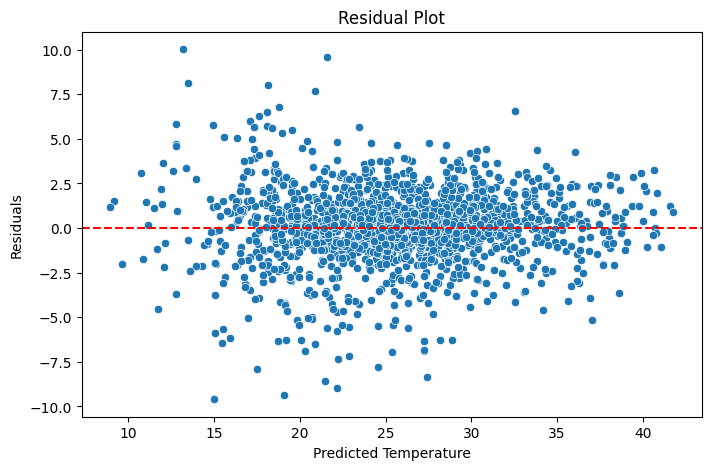

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Temperature")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

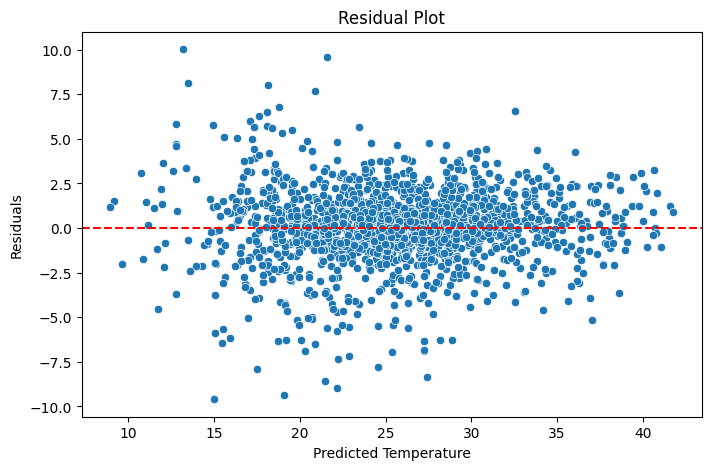

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Temperature")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

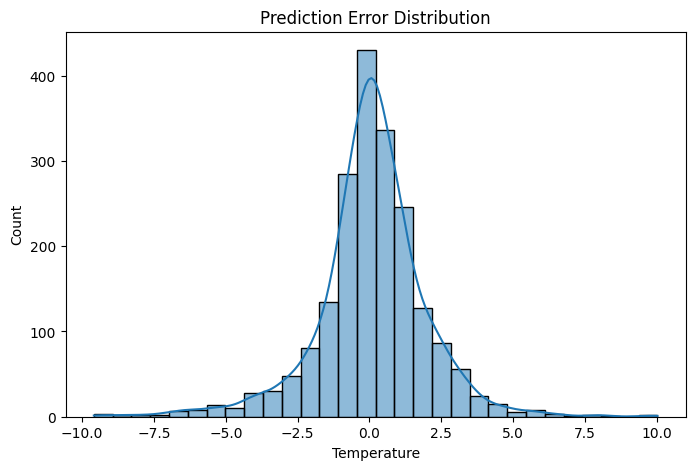

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Prediction Error Distribution")

plt.show()

In [10]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,Hour,0.264812
1,Humidity,0.202791
12,Season,0.171296
2,Pressure,0.146756
8,Month,0.093995
0,City,0.038576
9,Day,0.021207
3,Wind_Speed,0.019429
4,Cloud_Cover,0.017649
7,Year,0.014318


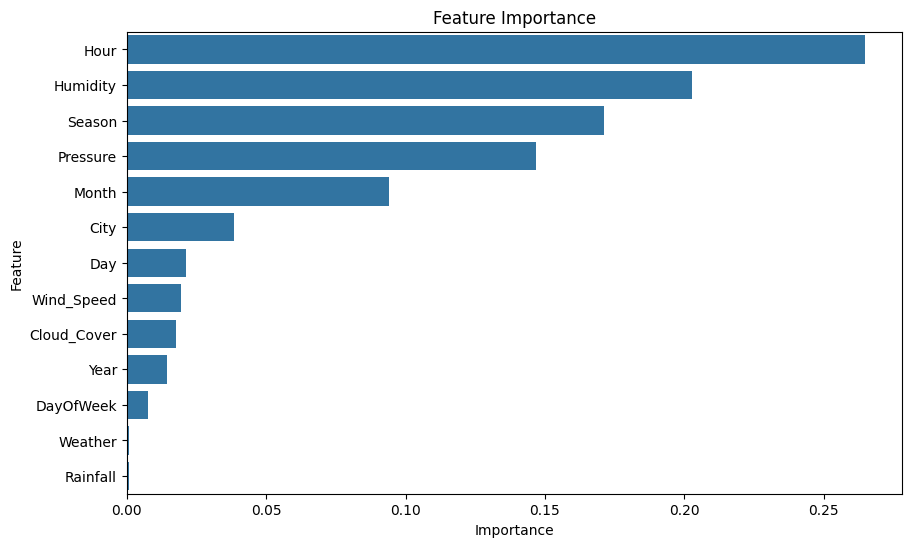

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance

)

plt.title("Feature Importance")

plt.show()

In [12]:
prediction = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})
from pathlib import Path

ROOT = Path.cwd().parent

prediction.to_csv(
    ROOT / "output" / "predictions.csv",
    index=False
)

In [13]:
prediction.head(20)

,Actual,Predicted
6252,28.9,26.490
4684,28.3,26.212
1731,12.9,15.620
4742,25.0,22.999
4521,23.8,18.087
6340,42.8,41.586
576,26.7,25.824
5202,24.2,25.072
6363,25.9,23.159
439,30.7,28.392


In [14]:
prediction["Error"] = abs(
    prediction["Actual"] -
    prediction["Predicted"]
)

prediction.sort_values(
    by="Error"
).head()

,Actual,Predicted,Error
8503,21.4,21.400,7.105427e-15
8478,24.1,24.100,1.065814e-14
2487,26.6,26.601,1.000000e-03
2133,24.8,24.802,2.000000e-03
9766,33.7,33.697,3.000000e-03


In [15]:
prediction.sort_values(
    by="Error",
    ascending=False
).head()

,Actual,Predicted,Error
866,23.2,13.175,10.025
1313,31.2,21.584,9.616
6217,5.4,14.994,9.594
8729,9.7,19.081,9.381
1254,13.2,22.150,8.950


In [16]:
from pathlib import Path

ROOT = Path.cwd().parent

graphs_dir = ROOT / "output" / "graphs"
graphs_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    graphs_dir / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [17]:
print(X.columns.tolist())

['City', 'Humidity', 'Pressure', 'Wind_Speed', 'Cloud_Cover', 'Weather', 'Rainfall', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Season']


In [18]:
print(df.head())

   City  Temperature  Humidity  Pressure  Wind_Speed  Cloud_Cover  Weather  \
0    31         13.7        81     925.7       24.12           57        0   
1     4         27.6        86    1002.0       40.68          100        1   
2     8         27.5        90    1002.3       46.80            0        0   
3    34         16.4        46     996.7       37.08            6        0   
4    29         25.6        64    1012.8       30.96           98        1   

   Rainfall  Year  Month  Day  Hour  DayOfWeek  Season  
0       0.0  2011     12   25     3          3       3  
1       0.0  2023      8    5    22          2       0  
2       0.0  2018      5   21     5          1       2  
3       0.0  2026      1   24    14          2       3  
4       0.0  2024      1   30     8          5       3  
